In [3]:
import numpy as np
import pandas as pd

In [4]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab

In [5]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error,root_mean_squared_error
from sklearn import metrics

In [7]:
data=pd.read_csv("/content/diamonds.csv")
data.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [8]:
print(data.shape)
print(data.columns)

(53940, 11)
Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')


In [9]:
data = data.drop(["Unnamed: 0"], axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [10]:
data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


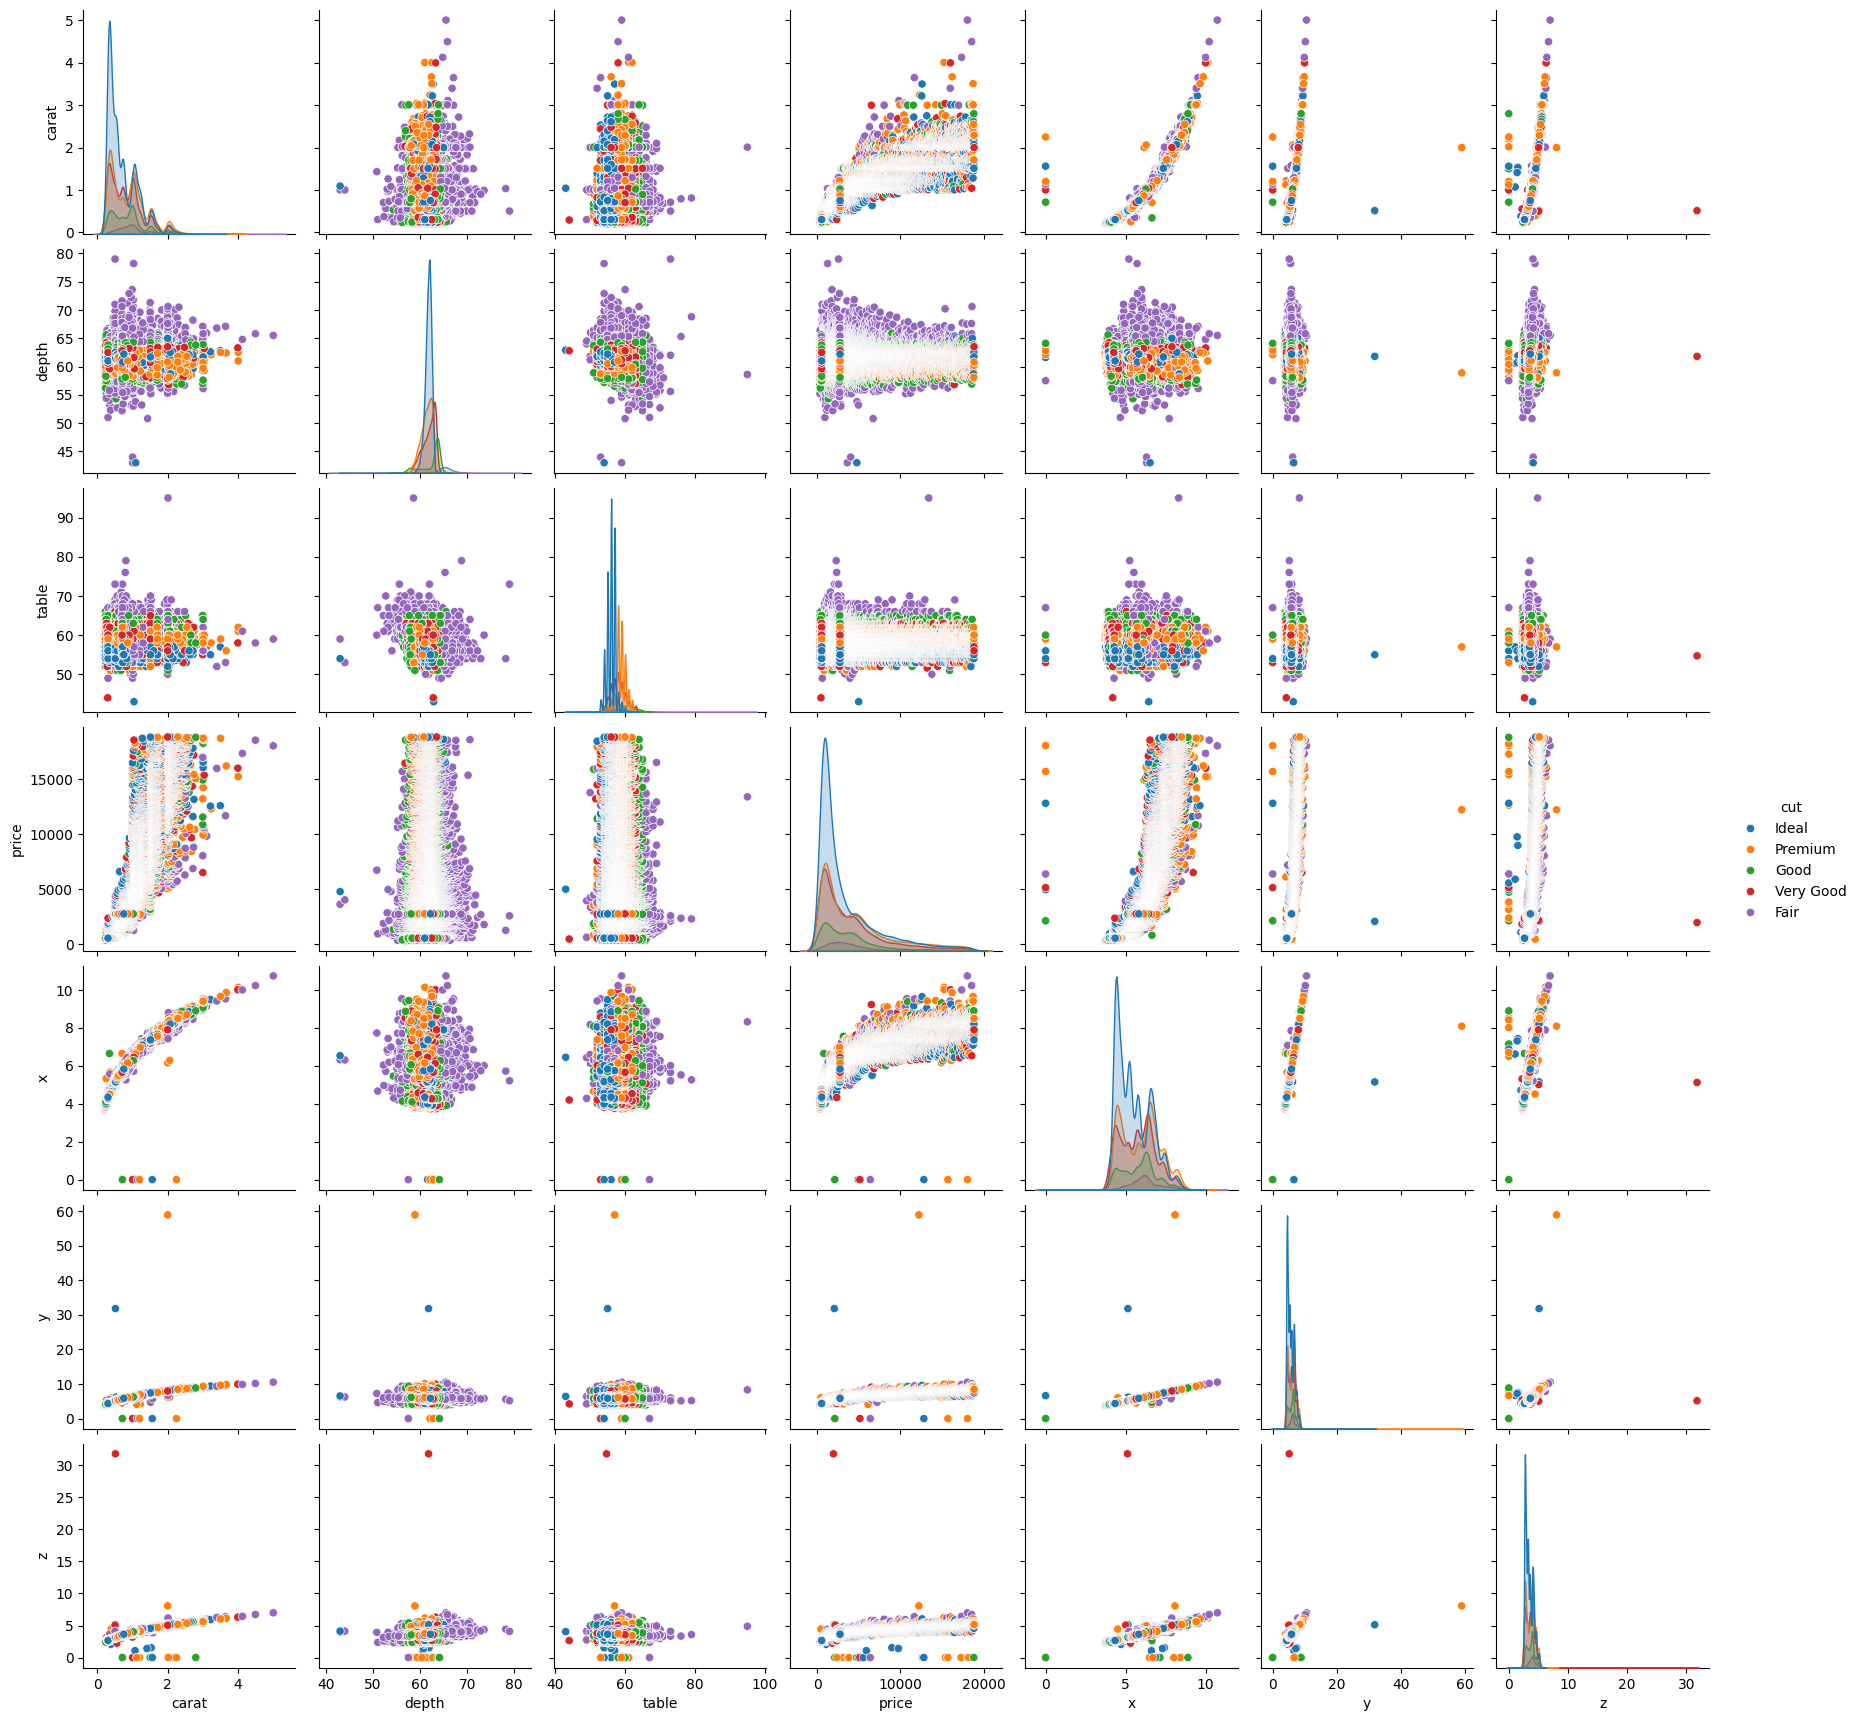

In [11]:
ax=sns.pairplot(data,hue='cut')

In [12]:
ax=sns.regplot(x="price",y="x",data=data, fit_reg=True, alpha=0.3)
ax.set_title("regression line price vs x")

TypeError: regplot() got an unexpected keyword argument 'alpha'

In [13]:
data=data[(data["x"]<10)]
data=data[(data["y"]<30)]
data=data[(data["z"]<15)&(data["z"]>2)]
data = data[(data["depth"]<75)&(data["depth"]>50)]
data = data[(data["table"]<85)&(data["table"]>45)]
data.shape

(53899, 10)

In [14]:
s=(data.dtypes=="object")
object_cols=list(s[s].index)
print('catigrical data:',object_cols)

catigrical data: ['cut', 'color', 'clarity']


In [ ]:
liner = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

In [18]:
lcoder= LabelEncoder()
data['Cut_label'] = lcoder.fit_transform(data['cut'])
data['Colour_label'] = lcoder.fit_transform(data['color'])
data['Clarity_label'] = lcoder.fit_transform(data['clarity'])

In [19]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,cut1,Cut_label,Colour_label,Clarity_label
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,2,2,1,3
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,3,3,1,2
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,1,1,1,4
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,3,3,5,5
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,1,1,6,3


In [20]:
X = data.drop(['cut1','cut','clarity','color','price'],axis=1)
Y = data['price']

In [23]:
Y.head()

,price
0,326
1,326
2,327
3,334
4,335


In [21]:
Xtrain, Xtest, Ytrian, Ytest = train_test_split(X,Y,random_state=42,test_size=0.2)

In [ ]:
model = liner.fit(Xtrain,Ytrian)
#ridge.fit(Xtrain, Ytrian)
#lasso.fit(Xtrain, Ytrian)
#degree = 2
#poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
#poly_model.fit(Xtrain, Ytrian)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.085e+10, tolerance: 6.927e+07
  model = cd_fast.enet_coordinate_descent(


Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [ ]:
#Y_pre = model.predict(Xtest)
#Y_pre = ridge.predict(Xtest)
#Y_pre = lasso.predict(Xtest)
#Y_pre = poly_model.predict(Xtest)

In [ ]:
mean_squared_error(Ytest,Y_pre)

992528.2221167686

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
gnb = GaussianNB()
gnb.fit(Xtrain, Ytrian)
y_pred_gnb = gnb.predict(Xtest)

# K-Nearest Neighbors Model
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(Xtrain, Ytrian)
y_pred_knn = knn.predict(Xtest)


In [ ]:
CNN, RNN, NLP,